# Loading modules

In [3]:
# WILD OAT https://github.com/asydesign/Wheat-Weed-Dataset
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import glob
import numpy as np
import random
import xml.etree.ElementTree as ET
from torchvision import transforms
import torch
from sklearn.metrics import f1_score, r2_score
from torch.utils.data import Dataset, WeightedRandomSampler
from typing import Tuple, Dict, List
import EN
import ResNet
import ViT
import PVTv2
import seaborn as sns
import pandas as pd
from utils.loss_utils import LabelSmoothingCrossEntropy

# Setup device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.cuda.is_available()

C:\Users\EuanH\anaconda3\Lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
C:\Users\EuanH\anaconda3\Lib\site-packages\timm\models\registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


True

# Loading Images from path

In [6]:
# Join images and labels together
dataset = []

for filename in glob.glob(r'./Dataset/cirsium arvense/*.jpg'): 
    im = Image.open(filename)
    dataset.append([im, "cirsium arvense"])

for filename in glob.glob(r'./Dataset/avena fatua/*.jpg'): 
    im = Image.open(filename)
    dataset.append([im, "avena fatua"])

for filename in glob.glob(r'./Dataset/setaria viridis/*.jpg'): 
    im = Image.open(filename)
    dataset.append([im, "setaria viridis"])

print(len(dataset))

2243


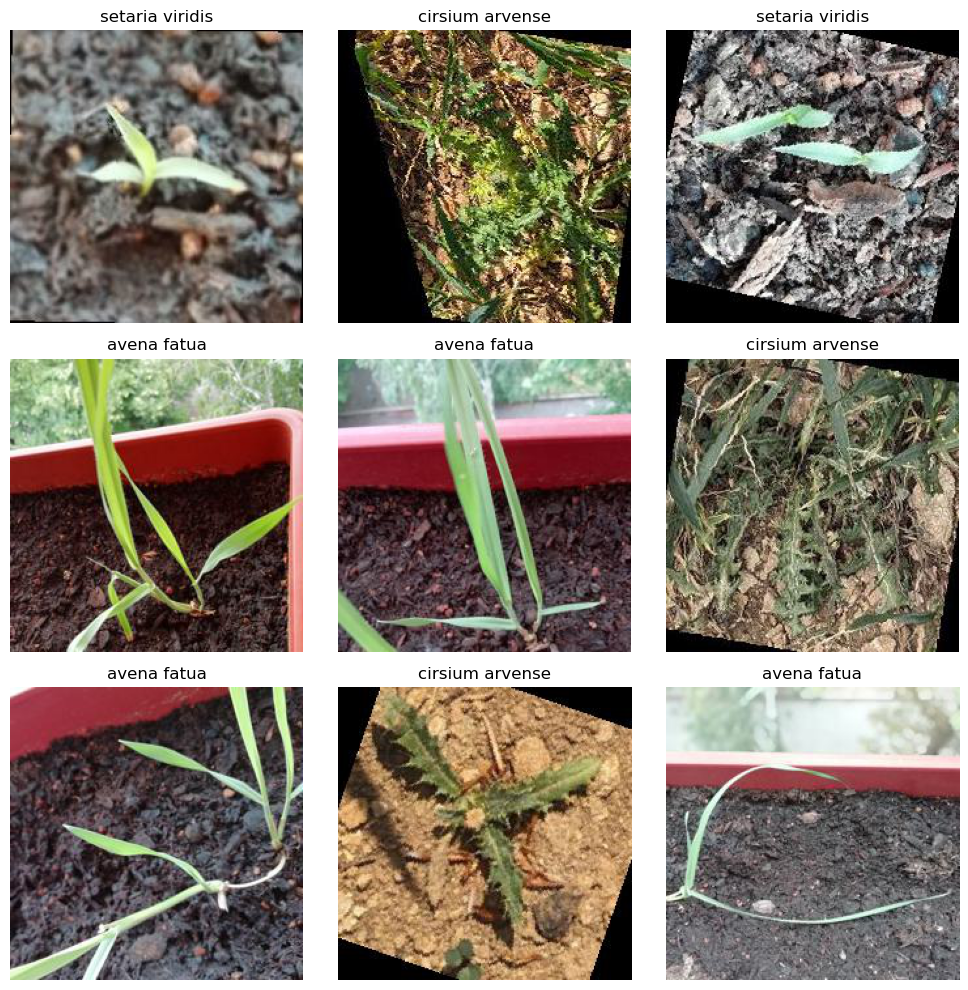

In [15]:
# CHECKING IF IMAGE IS NORMALIZED CORRECTLY
# Figure out how to extract the actual data from the images.
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for i in range(0, 9):
    ran = random.randint(0, len(dataset))
    axes[i].imshow(dataset[ran][0])
    axes[i].axis('off')
    axes[i].set_title(dataset[ran][1])
    
plt.tight_layout()
plt.show()

# Defining custom dataset

In [8]:
# Custom Dataset initialization 
class WeedsDataset(Dataset):
    # 2. Initialize with a targ_dir and transform (optional) parameter
    def __init__(self, dataset: str, transform=None) -> None:
        self.images = dataset
        self.transform = transform
        self.class_idx = {"cirsium arvense" : 0, "avena fatua" : 1, "setaria viridis" : 2}

    def load_image(self, index: int) -> Image.Image:
        #rint(self.images[index])
        return self.images[index][0]
    
    def __len__(self) -> int:
        return len(self.images)
    
    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        img = self.load_image(index)
        class_name  = self.images[index][1]
        class_idx = self.class_idx[class_name]

        if self.transform:
            return self.transform(img), class_idx # return data, label (X, y)
        else:
            return img, class_idx # return data, label (X, y)

# Defining Testing and Training Steps

In [9]:
from tqdm.auto import tqdm
import torch.nn as nn

# 1. Take in various parameters required for training and test steps
def train(model: torch.nn.Module, 
          train_dataloader: torch.utils.data.DataLoader, 
          test_dataloader: torch.utils.data.DataLoader, 
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):
    
    # 2. Create empty results dictionary
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
        "f1_score": [],
        "correct": [],
        "incorrect": [],
    }
    
    # 3. Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        test_loss, test_acc, f1_score, correct, incorrect = test_step(model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn)
        
        # 4. Print out what's happening
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f} | "
            f"F1-Score: {f1_score:.4f} | "
        )

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)
        results["f1_score"].append(f1_score.item() if isinstance(f1_score, torch.Tensor) else f1_score)
        results["correct"].append(correct.item() if isinstance(correct, torch.Tensor) else correct)
        results["incorrect"].append(incorrect.item() if isinstance(incorrect, torch.Tensor) else incorrect)


    # 6. Return the filled results at the end of the epochs
    return results

In [10]:
def train_step(model: torch.nn.Module, 
               dataloader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               optimizer: torch.optim.Optimizer):
    # Put model in train mode
    model.train()
    
    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0
    
    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        # Send data to target device
        X, y = X.to(device), y.to(device)
        # 1. Forward pass
        y_pred = model(X)

        loss = loss_fn(y_pred, y)
            
        train_loss += loss.item() 

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # Gradiant clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch 
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [11]:
def test_step(model: torch.nn.Module, 
              dataloader: torch.utils.data.DataLoader, 
              loss_fn: torch.nn.Module):
    # Put model in eval mode
    model.eval() 

    y_true = []
    y_p = []
    
    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0
    correct, incorrect = 0, 0

    
    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(device), y.to(device)
            
            # 1. Forward pass
            test_pred_logits = model(X)
                
            loss = loss_fn(test_pred_logits, y)
            
            test_loss += loss.item()
            
            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))
            #print((test_pred_labels == y).sum().item(), len(test_pred_labels))
            correct += (test_pred_labels == y).sum().item()
            incorrect += len(y) - (test_pred_labels == y).sum()

            
            # Calculate and accumulate accuracy metrics across all batches
            y_p.extend(test_pred_labels.cpu().numpy())
            y_true.extend(y.cpu().numpy())

    # Calculating precision, recall, and F1 score using PyTorch
    # Convert lists to tensors for calculation
    f1 = f1_score(y_true, y_p, average="macro")
    #print(f"Actual values: {set(y_true)} :: Predictions {set(y_p)}")
            
    # Adjust metrics to get average loss and accuracy per batch 
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc, f1, correct, incorrect

# Instanciating dataset with shuffles, augmentation, and normalisation

In [12]:
# Centering each image around 0 in a [-1, 1] range.
# https://medium.com/@piyushkashyap045/image-normalization-in-pytorch-from-tensor-conversion-to-scaling-3951b6337bc8 (Find more reliable source and cite)
mean = (0.5, 0.5, 0.5)
std = (0.5, 0.5, 0.5)
train_transforms = transforms.Compose([
    #transforms.TrivialAugmentWide(num_magnitude_bins=25), # how intense 
    #transforms.RandomHorizontalFlip(p=0.5),
    #transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean, std), # Is there any other way to normalize without calling compose twice?
    #transforms.RandomErasing(p=1), # Testing random erasure (not working for some reason)
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])


train_25 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std), 
    transforms.RandomErasing(p=0.25), # Testing random erasure (not working for some reason)
])


train_50 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std), 
    transforms.RandomErasing(p=0.5), # Testing random erasure (not working for some reason)
])

# Creating Test and Training sets 
length = len(dataset)
train_data_len = int(length*0.80)
train_data, test_data = train_set, val_set = torch.utils.data.random_split(dataset, [train_data_len, length-train_data_len])
train_data_0 = WeedsDataset(dataset=train_data, transform=train_transforms)
train_data_25 = WeedsDataset(dataset=train_data, transform=train_25)
train_data_50= WeedsDataset(dataset=train_data, transform=train_50)
test_data = WeedsDataset(dataset=test_data, transform=test_transforms)

from torch.utils.data import DataLoader

train_dataloader = DataLoader(dataset=train_data_0, # use custom created train Dataset
                                     batch_size=32, # how many samples per batch?
                                     num_workers=0, # how many subprocesses to use for data loading? (higher = more)
                                     shuffle=True) # shuffle the data?

train_dataloader_25 = DataLoader(dataset=train_data_25, # use custom created train Dataset
                                     batch_size=32, # how many samples per batch?
                                     num_workers=0, # how many subprocesses to use for data loading? (higher = more)
                                     shuffle=True) # shuffle the data?

train_dataloader_50 = DataLoader(dataset=train_data_50, # use custom created train Dataset
                                     batch_size=32, # how many samples per batch?
                                     num_workers=0, # how many subprocesses to use for data loading? (higher = more)
                                     shuffle=True) # shuffle the data?

test_dataloader = DataLoader(dataset=test_data, # use custom created test Dataset
                                    batch_size=32, 
                                    num_workers=0, 
                                    shuffle=False) # don't usually need to shuffle testing data


TypeError: object of type 'Compose' has no len()

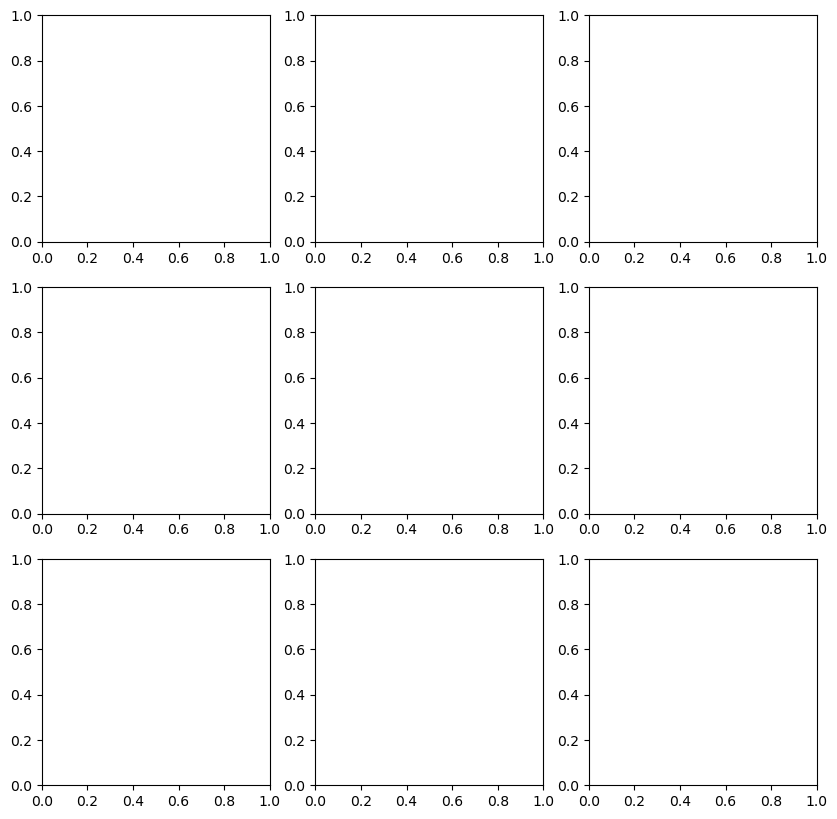

In [17]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for i in range(0, 9):
    ran = random.randint(0, len(train_25))
    axes[i].imshow(train_25[0])
    axes[i].axis('off')
    
plt.tight_layout()
plt.show()

In [13]:
## Training

# Set random seeds
torch.manual_seed(42) 
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 50

torch.autograd.set_detect_anomaly(False)
#EffNet = EfficientNet.EfficientNet("B1", in_channels=3, classes=3, show=False).to(device) # EfficientNet-B0 FIGURE OUT WHY TEST ACC ISN'T SHOWING
#RsNet = ResNet.ResNet50(channels=3, num_classes=3).to(device) # ResNet - FIGURE OUT WHY TEST ACC IS AT 100% ALL THE TIME


#vit_b16 = ViT.ViTClassifier(img_batch, num_classes=3).to(device) 
PvTv2 = PVTv2.pvt_v2_b0(num_classes=3, pretrained=None).to(device) 

# Setup loss function and optimizer
#loss_fn = nn.CrossEntropyLoss()
loss = LabelSmoothingCrossEntropy().to(device)



# Start the timer
from timeit import default_timer as timer 
# Creating Test and Training sets 
length = len(dataset)
train_data_len = int(length*0.80)
train_data, test_data = train_set, val_set = torch.utils.data.random_split(dataset, [train_data_len, length-train_data_len])

#start_time = timer()

# Train model_0 
#img_batch, label_batch = next(iter(train_dataloader))
#import EfficientNet
#PvTv2 = PVTv2.pvt_v2_b0(num_classes=3, pretrained=None).to(device) 
rsnet = ResNet.ResNet50(channels=3, num_classes=3).to(device) # ResNet - FIGURE OUT WHY TEST ACC IS AT 100% ALL THE TIME
#vit_b16 = ViT.ViTClassifier(img_batch, num_classes=3).to(device) 
optimizer_0 = torch.optim.AdamW(params=rsnet.parameters(), lr=0.00001)
v_0 = train(model=rsnet, 
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer_0,
                        loss_fn=loss, 
                        epochs=NUM_EPOCHS)


#img_batch, label_batch = next(iter(train_dataloader_25))
#vit_b16_25 = ViT.ViTClassifier(img_batch, num_classes=3).to(device) 
#optimizer_0 = torch.optim.AdamW(params=vit_b16_25.parameters(), lr=0.00001) #EN.EfficientNet("B0", in_channels=3, classes=3, show=False).to(device) #
#v_25 = train(model=vit_b16_25, 
#                        train_dataloader=train_dataloader_25,
#                        test_dataloader=test_dataloader,
#                        optimizer=optimizer_0,
#                        loss_fn=loss, 
#                        epochs=NUM_EPOCHS)

#img_batch, label_batch = next(iter(train_dataloader_50))
#img_batch, label_batch = next(iter(train_dataloader_50))
#vit_b16_50 = ViT.ViTClassifier(img_batch, num_classes=3).to(device)   #EN.EfficientNet("B0", in_channels=3, classes=3, show=False).to(device) #
#optimizer_1 = torch.optim.AdamW(params=vit_b16_50.parameters(), lr=0.00001)
#v_50 = train(model=vit_b16_50, 
#                        train_dataloader=train_dataloader_50,
#                        test_dataloader=test_dataloader,
#                        optimizer=optimizer_1,
#                        loss_fn=loss, 
#                        epochs=NUM_EPOCHS)

#end_time = timer()
#print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.9947 | train_acc: 0.5252 | test_loss: 1.0439 | test_acc: 0.5354 | F1-Score: 0.4028 | 
Epoch: 2 | train_loss: 0.8561 | train_acc: 0.6749 | test_loss: 0.8840 | test_acc: 0.6521 | F1-Score: 0.6956 | 
Epoch: 3 | train_loss: 0.7102 | train_acc: 0.7708 | test_loss: 0.7196 | test_acc: 0.7917 | F1-Score: 0.7606 | 
Epoch: 4 | train_loss: 0.6069 | train_acc: 0.8295 | test_loss: 0.6209 | test_acc: 0.7833 | F1-Score: 0.8308 | 
Epoch: 5 | train_loss: 0.5415 | train_acc: 0.8662 | test_loss: 0.5727 | test_acc: 0.8187 | F1-Score: 0.8749 | 
Epoch: 6 | train_loss: 0.4959 | train_acc: 0.8969 | test_loss: 0.5970 | test_acc: 0.8271 | F1-Score: 0.8866 | 
Epoch: 7 | train_loss: 0.4883 | train_acc: 0.9024 | test_loss: 0.7459 | test_acc: 0.8000 | F1-Score: 0.8587 | 


KeyboardInterrupt: 

# Plotting Results

    train_loss  train_acc  test_loss  test_acc  f1_score  correct  incorrect
0     0.800436   0.674890   0.597332  0.837500  0.832404      371         78
1     0.634857   0.789474   0.604412  0.856250  0.850351      380         69
2     0.559233   0.842654   0.500504  0.883333  0.877506      393         56
3     0.493282   0.889803   0.561761  0.860417  0.854693      382         67
4     0.456636   0.914474   0.652615  0.864583  0.859376      384         65
5     0.475177   0.896382   0.527228  0.881250  0.877267      392         57
6     0.461515   0.901316   0.479311  0.902083  0.899062      402         47
7     0.455053   0.915022   0.573993  0.875000  0.870425      389         60
8     0.425531   0.932566   0.425704  0.943750  0.942464      422         27
9     0.417846   0.934211   0.418233  0.935417  0.933293      418         31
10    0.390749   0.947368   0.571993  0.883333  0.878989      393         56
11    0.408002   0.934759   0.497971  0.920833  0.917763      411         38

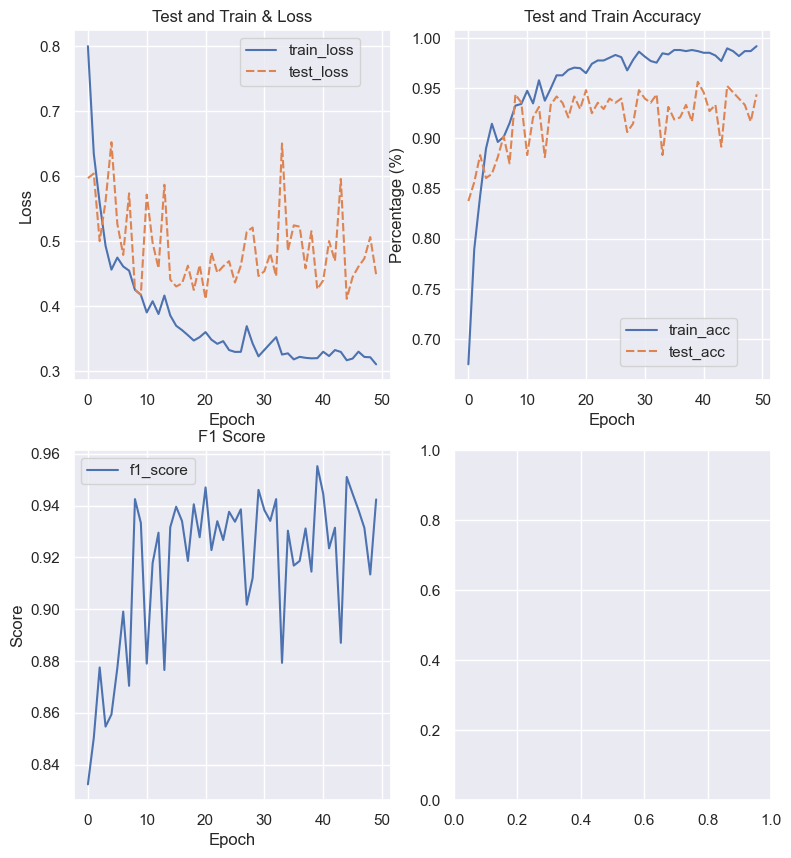

In [10]:
x = [i for i in range(1, NUM_EPOCHS+1)]

title = ['Train Accuracy & Loss', 'Test Accuracy & Loss', 'F1 Score']
labels = ['train_loss', 'train_acc', 'test_loss', 'test_acc', 'f1_score']

# CHECKING IF IMAGE IS NORMALIZED CORRECTLY
# Figure out how to extract the actual data from the images.
model_0_results = v_25
df = pd.DataFrame(model_0_results)
print(df)
sns.set_theme()
f, axes = plt.subplots(2, 2, figsize=(9, 10))
axes = axes.flatten()
ax = sns.lineplot(data=df[["train_loss", "test_loss"]], ax=axes[0])
ax.set(title="Test and Train & Loss", ylabel="Loss", xlabel="Epoch")
lgd = sns.move_legend(ax, "upper left", bbox_to_anchor=(0.5,1))


ax2 = sns.lineplot(data=df[["train_acc", "test_acc"]], ax=axes[1])
ax2.set(title="Test and Train Accuracy", ylabel="Percentage (%)", xlabel="Epoch")
lgd2 = sns.move_legend(ax2, "upper left", bbox_to_anchor=(0.5,0.2))

ax3 = sns.lineplot(data=df[["f1_score"]], ax=axes[2])
ax3.set(title="F1 Score", ylabel="Score", xlabel="Epoch")
lgd3 = sns.move_legend(ax2, "upper left", bbox_to_anchor=(0.5,0.2))
fig = f.get_figure()
fig.savefig("ViT 32 Batch 50 Epoch 25% LabelSmoothingCrossEntropy.png")

df.to_csv("vit 50 25%.csv", index=True)